In [14]:
import numpy as np
import pandas as pd

from scipy.signal import find_peaks, czt, welch
from scipy.stats import linregress, skew, kurtosis
from itertools import permutations
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import classification_report, confusion_matrix

In [15]:
results = []

In [16]:
quadrants_all = [
    "Q1_1",
    "Q1_2",
    "Q2_1",
    "Q2_2",
    "Q3_1",
    "Q3_2",
    "Q4_1",
    "Q4_2",
    "Q5_1",
    "Q5_2",
    "Q6_1",
    "Q6_2",
    "Q7_1",
    "Q7_2",
    "Q8_1",
    "Q8_2",
    "Q9_1",
    "Q9_2"
]

quadrants_arousal = [
    "Q1_1",
    "Q1_2",
    "Q2_1",
    "Q2_2",
    "Q3_1",
    "Q3_2",
    "Q7_1",
    "Q7_2",
    "Q8_1",
    "Q8_2",
    "Q9_1",
    "Q9_2"
]

quadrants_valence = [
    "Q1_1",
    "Q1_2",
    "Q3_1",
    "Q3_2",
    "Q4_1",
    "Q4_2",
    "Q6_1",
    "Q6_2",
    "Q7_1",
    "Q7_2",
    "Q9_1",
    "Q9_2"
]

quadrants_5q = [
    "Q1_1",
    "Q1_2",
    "Q3_1",
    "Q3_2",
    "Q5_1",
    "Q5_2",
    "Q7_1",
    "Q7_2",
    "Q9_1",
    "Q9_2"
]


quadrants_4q = [
    "Q1_1",
    "Q1_2",
    "Q3_1",
    "Q3_2",
    "Q7_1",
    "Q7_2",
    "Q9_1",
    "Q9_2"
]

In [1]:
quadrants = quadrants_4q

NameError: name 'quadrants_4q' is not defined

In [18]:
base_path_video = "../BVPs"

failed_masks = [
    [2, "Q1_1"],
    [52, "Q7_2"],
    [53, "Q4_2"]
]

label_map = {
    "Q1": "Q1: ↑Arousal ↓Val",
    "Q2": "Q2: ↑Arousal -Val",
    "Q3": "Q3: ↑Arousal ↑Val",
    "Q4": "Q4: -Arousal ↓Val",
    "Q5": "Q5: -Arousal -Val",
    "Q6": "Q6: -Arousal ↑Val",
    "Q7": "Q7: ↓Arousal ↓Val",
    "Q8": "Q8: ↓Arousal -Val",
    "Q9": "Q9: ↓Arousal ↑Val",
}

patients = list(range(1, 62))
patients.remove(23)

#patients = expressive

class BVP:
    def __init__(self, patient, quadrant, signal, features, id):
        self.patient = patient
        self.quadrant = quadrant
        self.signal = signal
        self.features = features
        self.id = id

In [19]:
def cut_bvp(bvp, t_start, t_end, fs=60):
    n = len(bvp)

    # Convert time to sample indices
    n_start = int(t_start * fs)
    n_end = int(t_end * fs)

    # Clamp to valid range
    n_start = max(0, min(n_start, n))
    n_end = max(0, min(n_end, n))

    return bvp[n_start:n_end]

def cut_bvp_last(bvp, length, fs=60):
    
    n_samples = int(length * fs)
    
    if n_samples >= len(bvp):
        return bvp  # return full signal if shorter than requested
    
    return bvp[-n_samples:]

def cut_au_last(df, length, fs=60):

    n_samples = int(length * fs)

    if n_samples >= len(df):
        return df

    return df.iloc[-n_samples:]

In [20]:
def get_label(path):
    q = path.split("_")[0]  # "Q3_2" → "Q3"
    return label_map[q]

# def get_label(path):
#     q = path.split("_")[0]

#     if q in ["Q1", "Q3"]:
#         return "HighArousal"
#     else:
#         return "LowArousal"

In [21]:
def window_bvp(bvp, window_sec=3.0, fs=60):

    bvp = np.asarray(bvp, dtype=float)
    win_len = int(window_sec * fs)

    windows = []

    # Regular windows
    for start in range(0, len(bvp) - win_len + 1, win_len):
        windows.append(bvp[start:start + win_len])

    # Force final window (end-aligned)
    end_start = len(bvp) - win_len
    if end_start > 0 and end_start not in range(0, len(bvp) - win_len + 1, win_len):
        windows.append(bvp[end_start:end_start + win_len])

    return windows

In [23]:
def window_au_df(df, window_sec=3.0, fs=60):

    win_len = int(window_sec * fs)

    if len(df) < 2 * win_len:
        return None

    windows = []

    # regular windows
    for start in range(0, len(df) - win_len + 1, win_len):
        windows.append(df.iloc[start:start + win_len])

    # force final window (end-aligned)
    end_start = len(df) - win_len
    if end_start > 0 and end_start not in range(0, len(df) - win_len + 1, win_len):
        windows.append(df.iloc[end_start:end_start + win_len])

    return windows

In [24]:
def compute_features_bvp(bvp, fs=60):
    """
    Compute BVP features from a single short window.
    Returns a dictionary (same format as previous function).
    """

    if len(bvp) < fs:  # less than 1 second
        return None
    

    # ---- Remove DC component ----
    bvp = bvp - np.mean(bvp)

    # ---- Time-domain features ----
    features = {}

    features["bvp_std"] = np.std(bvp)
    features["bvp_min"] = np.min(bvp)
    features["bvp_max"] = np.max(bvp)
    features["bvp_ptp"] = np.ptp(bvp)              # peak-to-peak
    features["bvp_energy"] = np.sum(bvp ** 2)
    features["bvp_skew"] = skew(bvp)
    features["bvp_kurtosis"] = kurtosis(bvp)

    # ---- Frequency-domain features ----
    # freqs, psd = welch(bvp, fs=fs)
    freqs, psd = welch(bvp, fs=fs, nperseg=len(bvp))

    features["bvp_total_power"] = np.sum(psd)
    features["bvp_dominant_freq"] = freqs[np.argmax(psd)]


    return features

In [26]:
def compute_features_au(df):

    # select AU intensity columns
    au_cols = [c for c in df.columns if "_r" in c]

    features = {}

    for col in au_cols:
        features[f"{col}"] = df[col].mean()

    # for col in au_cols:
    #     features[f"{col}_mean"] = df_window[col].mean()
    #     features[f"{col}_std"] = df_window[col].std()
    #     features[f"{col}_max"] = df_window[col].max()

    return features


In [ ]:
def compute_features_both_window(
    bvp,
    window_sec=5.0,
    total_vid_size=15,
    fs = 60
):
    
    window_features = []

    patient = f"Patient_{bvp.patient}"
    quadrant = bvp.quadrant

    path_aus = rf"C:\Users\mique\OneDrive\Dokumenty\GitHub\POS\Gesture Emotion Prediction\Results\{patient}\{quadrant}\vid_crop.csv"

    df = pd.read_csv(path_aus)

    windows_au = window_au_df(df, window_sec, fs)

    bvp = np.asarray(bvp.signal)

    windows_bvp = window_bvp(bvp, window_sec, fs)

    if len(window_bvp) != len(windows_au):
        print(f"Not matching window length of {patient}, {quadrant}")

    for idx in range(len(windows_bvp)):

        feats_bvp = compute_features_bvp(
            bvp,
            fs
        )

        # feats_bvp = compute_bvp_short_window_features(
        #     w,
        #     fs
        # )

        if any(np.isnan(v) for v in feats_bvp.values()):
            print(f"Nan found in BVP of {patient}, {quadrant}")
            continue

        # window_features.append(feats_bvp)

    #print(f"Computing Gesture Features for {patient}...", end="\r", flush=True)



    for au in windows_au:

        feats_au = compute_features_au(au)

        if any(np.isnan(v) for v in feats_au.values()):
            print(f"Nan found in AUs of {patient}, {quadrant}")
            continue

        # window_features.append(feats)

    window_features =  {**feats_bvp, **feats_au}

    if len(window_features) < 2:
        return None

    # --------------------------------------------------
    # 3. Aggregate across windows
    # --------------------------------------------------
    feature_names = list(window_features[0].keys())
    features = {}

    for name in feature_names:
        values = np.array([wf[name] for wf in window_features])

        features[f"{name}_mean"] = np.mean(values)
        features[f"{name}_std"] = np.std(values)
        features[f"{name}_range"] = np.max(values) - np.min(values)


    return features

In [29]:
# Load BVPs

fs = 60  # sampling rate

BVPs = []

for patient in patients:

    for quadrant in quadrants:

        if [patient, quadrant] in failed_masks:
            print(f"Skipping Patient_{patient}, {quadrant}")
            continue

        data = np.load(f"{base_path_video}/Patient_{patient}/{quadrant}.npy")

        id = f"{patient}{quadrant}"

        bvp = BVP(patient, quadrant, data, [], id)

        BVPs.append(bvp)

        #print(f"Patient_{patient}, {path}: {data.shape}")

print(f"Loaded {len(BVPs)} BVP signals")


Skipping Patient_2, Q1_1
Skipping Patient_52, Q7_2
Loaded 478 BVP signals


In [30]:
window_length = 3
full_vid_size = 18

In [31]:
valid = []
failed = []

for bvp in BVPs:  # use a copy to safely remove items

    print(f"Computing Features for Patient_{bvp.patient}...", end="\r", flush=True)
    
    try:
        # Use the new windowed feature extraction
        feats = compute_features_both_window(bvp, window_length, full_vid_size, fs=60)

        if feats is None or feats == []:
            print(f"Failed: Patient_{bvp.patient}, {bvp.quadrant}")
            failed.append(f"Patient_{bvp.patient}, {bvp.quadrant}")
            BVPs.remove(bvp)  # remove problematic signal
        else:
            bvp.features = feats
            valid.append(f"Patient_{bvp.patient}, {bvp.quadrant}")

    except Exception as e:
        print(f"Error for Patient_{bvp.patient}, {bvp.quadrant}: {e}")
        failed.append(f"Patient_{bvp.patient}, {bvp.quadrant}")
        BVPs.remove(bvp)

print(f"Extracted features for {len(valid)} videos")
print(f"Failed: {failed}")

Error for Patient_1, Q1_1: 0nt_1...
Error for Patient_1, Q3_1: 0nt_1...
Error for Patient_1, Q7_1: 0nt_1...
Error for Patient_1, Q9_1: 0nt_1...
Error for Patient_2, Q1_2: 0nt_2...
Error for Patient_2, Q3_2: 0nt_2...
Error for Patient_2, Q7_2: 0nt_2...
Error for Patient_2, Q9_2: 0nt_2...
Error for Patient_3, Q1_2: 0nt_3...
Error for Patient_3, Q3_2: 0nt_3...
Error for Patient_3, Q7_2: 0nt_3...
Error for Patient_3, Q9_2: 0nt_3...
Error for Patient_4, Q1_2: 0nt_4...
Error for Patient_4, Q3_2: 0nt_4...
Error for Patient_4, Q7_2: 0nt_4...
Error for Patient_4, Q9_2: 0nt_4...
Error for Patient_5, Q1_2: 0nt_5...
Error for Patient_5, Q3_2: 0nt_5...
Error for Patient_5, Q7_2: 0nt_5...
Error for Patient_5, Q9_2: 0nt_5...
Error for Patient_6, Q1_2: 0nt_6...
Error for Patient_6, Q3_2: 0nt_6...
Error for Patient_6, Q7_2: 0nt_6...
Error for Patient_6, Q9_2: 0nt_6...
Error for Patient_7, Q1_2: 0nt_7...
Error for Patient_7, Q3_2: 0nt_7...
Error for Patient_7, Q7_2: 0nt_7...
Error for Patient_7, Q9_2: 0

KeyboardInterrupt: 

In [ ]:
window_features = []

windows_bvp = window_bvp(bvp, window_length, fs)

patient = f"Patient_{patient}"

#print(f"Computing Gesture Features for {patient}...", end="\r", flush=True)

path = rf"C:\Users\mique\OneDrive\Dokumenty\GitHub\POS\Gesture Emotion Prediction\Results\{patient}\{quadrant}\vid_crop.csv"

df = pd.read_csv(path)

windows_au = window_au_df(df, window_length, fs)

for w in windows:

    feats = compute_bvp_arousal_features(
        w,
        fs,
        fmin=fmin,
        fmax=fmax,
        n_czt_bins=n_czt_bins
    )

    # feats = compute_bvp_short_window_features(
    #     w,
    #     fs
    # )

    if any(np.isnan(v) for v in feats.values()):
        continue

    window_features.append(feats)

if len(window_features) < 2:
    return None

# --------------------------------------------------
# 3. Aggregate across windows
# --------------------------------------------------
feature_names = list(window_features[0].keys())
features = {}

for name in feature_names:
    values = np.array([wf[name] for wf in window_features])

    features[f"{name}_mean"] = np.mean(values)
    features[f"{name}_std"] = np.std(values)
    features[f"{name}_range"] = np.max(values) - np.min(values)

In [89]:
valid = []
failed = []

for bvp in BVPs:  # use a copy to safely remove items

    print(f"Computing Features for Patient_{bvp.patient}...", end="\r", flush=True)
    
    try:
        # Use the new windowed feature extraction
        feats = compute_features_both(timestamps, bvp, fs)

        if feats is None or feats == []:
            print(f"Failed: Patient_{bvp.patient}, {bvp.quadrant}")
            failed.append(f"Patient_{bvp.patient}, {bvp.quadrant}")
            BVPs.remove(bvp)  # remove problematic signal
        else:
            bvp.features = feats
            valid.append(f"Patient_{bvp.patient}, {bvp.quadrant}")

    except Exception as e:
        print(f"Error for Patient_{bvp.patient}, {bvp.quadrant}: {e}")
        failed.append(f"Patient_{bvp.patient}, {bvp.quadrant}")
        BVPs.remove(bvp)

print(f"Extracted features for {len(valid)} videos")
print(f"Failed: {failed}")

Failed: Patient_9, Q7_2Patient_9...
Failed: Patient_14, Q1_2atient_14...
Failed: Patient_60, Q3_2atient_60...
Extracted features for 472 videos...
Failed: ['Patient_9, Q7_2', 'Patient_14, Q1_2', 'Patient_60, Q3_2']


In [90]:
pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced"
        ))
    ])

X = []
y = []
groups = []

for bvp in BVPs:
    if bvp is None or bvp.features == []:
        print("Error: Patient", bvp.patient, bvp.quadrant)
        continue
    
    feat_values = list(bvp.features.values())
    X.append(feat_values)
    y.append(get_label(bvp.quadrant))
    groups.append(bvp.id)  
    

X = np.array(X)
y = np.array(y)

print(X.shape, y.shape)
print(np.unique(y, return_counts=True))
print("Example of data: ", X[0])

Error: Patient 9 Q9_1
Error: Patient 14 Q3_1
Error: Patient 60 Q7_1
(472, 26) (472,)
(array(['Q1: ↑Arousal ↓Val', 'Q3: ↑Arousal ↑Val', 'Q7: ↓Arousal ↓Val',
       'Q9: ↓Arousal ↑Val'], dtype='<U17'), array([118, 118, 117, 119], dtype=int64))
Example of data:  [ 0.0999455  -0.18332095  0.23645538  0.41977634  3.59607695  0.38301308
 -0.54811811  0.06175084  1.16666667  0.35044321  0.07972299  0.74587258
  0.01711911  0.84842105  0.49479224  0.1398615   1.51584488  1.14274238
  1.06908587  0.12850416  0.25199446  0.07825485  0.11185596  0.37725762
  0.30548476  0.38224377]


In [91]:
cv = StratifiedGroupKFold(n_splits=5)

classif_reports = []
conf_matrix = []
f1_scores = []

from collections import Counter
print("Class distribution:", Counter(y))

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups)):
    print(f"Fold {fold}")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]


    pipe.fit(X_train, y_train)
    score = pipe.score(X_test, y_test)

    print("Score:", score)

    y_pred = pipe.predict(X_test)

    report_dict = classification_report(y_test, y_pred, output_dict=True)

    classif_reports.append(classification_report(y_test, y_pred))
    conf_matrix.append(confusion_matrix(y_test, y_pred))
    f1_scores.append(report_dict["macro avg"]["f1-score"])


Class distribution: Counter({'Q9: ↓Arousal ↑Val': 119, 'Q1: ↑Arousal ↓Val': 118, 'Q3: ↑Arousal ↑Val': 118, 'Q7: ↓Arousal ↓Val': 117})
Fold 0
Score: 0.3684210526315789
Fold 1
Score: 0.3723404255319149
Fold 2
Score: 0.2872340425531915
Fold 3
Score: 0.4
Fold 4
Score: 0.4574468085106383


In [92]:
report, matrix, f1_scores = classif_reports, conf_matrix, f1_scores

In [93]:
print("F1-Scores:", [f"{score:.2f}" for score in f1_scores[:5]])
print()
print(f"Average F1-Score: {sum(f1_scores)/5}")
print()
for idx in range(5):
    print(report[idx])
    print(matrix[idx])
    print()
    print("-"*50)

F1-Scores: ['0.37', '0.37', '0.28', '0.41', '0.46']

Average F1-Score: 0.37873884637591193

                   precision    recall  f1-score   support

Q1: ↑Arousal ↓Val       0.40      0.42      0.41        24
Q3: ↑Arousal ↑Val       0.63      0.50      0.56        24
Q7: ↓Arousal ↓Val       0.20      0.22      0.21        23
Q9: ↓Arousal ↑Val       0.31      0.33      0.32        24

         accuracy                           0.37        95
        macro avg       0.38      0.37      0.37        95
     weighted avg       0.39      0.37      0.38        95

[[10  3  6  5]
 [ 4 12  4  4]
 [ 8  1  5  9]
 [ 3  3 10  8]]

--------------------------------------------------
                   precision    recall  f1-score   support

Q1: ↑Arousal ↓Val       0.30      0.25      0.27        24
Q3: ↑Arousal ↑Val       0.61      0.48      0.54        23
Q7: ↓Arousal ↓Val       0.24      0.26      0.25        23
Q9: ↓Arousal ↑Val       0.39      0.50      0.44        24

         accuracy      

In [94]:
import pandas as pd

# feature names from BVP objects (windowed)
feature_names = list(BVPs[0].features.keys())

# extract RF importances from pipeline
importances = pipe.named_steps['clf'].feature_importances_

# build DataFrame
imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(imp_df)


              feature  importance
17             AU12_r    0.055302
19             AU15_r    0.055245
12             AU05_r    0.054916
23             AU25_r    0.052280
20             AU17_r    0.051387
15             AU09_r    0.050842
25             AU45_r    0.050646
13             AU06_r    0.046923
22             AU23_r    0.045725
10             AU02_r    0.041102
18             AU14_r    0.041004
21             AU20_r    0.038451
14             AU07_r    0.038392
9              AU01_r    0.037722
16             AU10_r    0.036655
24             AU26_r    0.036494
11             AU04_r    0.035588
6        bvp_kurtosis    0.031245
5            bvp_skew    0.029366
1             bvp_min    0.027788
7     bvp_total_power    0.027486
3             bvp_ptp    0.026307
2             bvp_max    0.025360
4          bvp_energy    0.025346
0             bvp_std    0.023766
8   bvp_dominant_freq    0.014662


In [95]:
results.append((f1_scores, common_window_size))

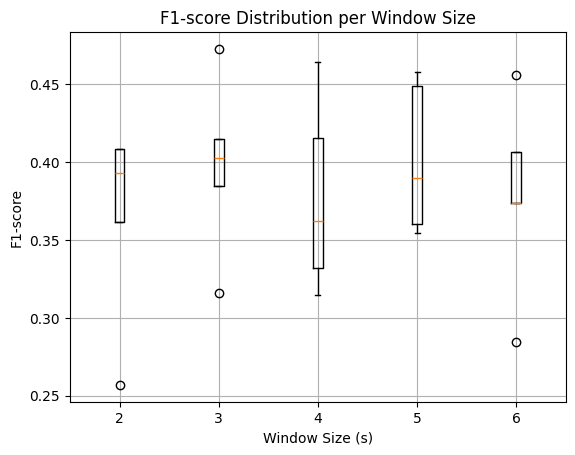

In [96]:
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

grouped = defaultdict(list)

for f1, win_size in results:
    grouped[win_size].append(f1)

window_sizes = sorted(grouped.keys())
f1_lists = [np.array(grouped[w]).ravel() for w in window_sizes]

plt.figure()

plt.boxplot(
    f1_lists,
    positions=window_sizes,
    widths=0.1
)

plt.xlabel("Window Size (s)")
plt.ylabel("F1-score")
plt.title("F1-score Distribution per Window Size")

plt.xticks(window_sizes)      # ensure ticks match window sizes
plt.grid(True)

plt.show()

In [97]:
# np.save("f1_scores_CUT.npy", np.array(results, dtype=object))



In [98]:
# a = np.load("f1_scores_CUT.npy", allow_pickle=True)

# for i in a:
#     print(f"Window Size: {i[1]} -> {i[0]}")